### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2026-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on [Teide](https://teide.ensimag.fr/) before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP1: Analysis of prostate cancer data

A medical study done on patients with prostate cancer aims to analyze the correlation between the prostate tumor volume and a set of clinical and morphometric variables. These variables include prostate specific antigens, a biomarker for prostate cancer, and a number of clinical measures (age, prostate weight, etc). The goal of this lab is to build a regression model to predict the severity of cancer, expressed by logarithm of the tumor volume -- `lcavol` variable -- from the following predictors:
- `lpsa`: log of a prostate specific antigen
- `lweight`: log of prostate weight
- `age`: age of the patient
- `lbph`: log of benign prostatic hyperplasia amount
- `svi`: seminal vesicle invasion
- `lcp`: log of capsular penetration
- `gleason`: Gleason score (score on a cancer prognosis test)
- `pgg45`: percent of Gleason scores 4 or 5

The file `prostate.data`, available [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP1/prostate.data), contains measures of the logarithm of the tumor
volume and of the 8 predictors for 97 patients. This file also contains an additional variable, called `train`, which will
not be used and has to be removed.

## ▶️ Exercise 1: Preliminary analysis of the data (1 points)

**(a)** Download the file `prostate.data` and store it in your current folder. Read the dataset in using `pandas` as per
```
import pandas as pd
df = pd.read_csv("prostate.data", sep="\t")
```
check how to use function `df.drop` to remove the first and last columns of `df` containing useless tags.

In [8]:
import numpy as np
import pandas as pd
from pathlib import Path
from urllib.request import urlretrieve

# Download data locally (only once)
data_path = Path("prostate.data")
if not data_path.exists():
    url = "https://raw.githubusercontent.com/ISLA-Grenoble/2025-main/main/TP/TP1/prostate.data"
    urlretrieve(url, data_path)

# Read file and remove useless first/last columns
df_raw = pd.read_csv(data_path, sep="\t")
df = df_raw.drop(columns=[df_raw.columns[0], "train"])

print(f"Shape after cleanup: {df.shape}")
display(df.head())
display(df.dtypes.to_frame("dtype").T)

Shape after cleanup: (97, 9)


,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45,lpsa
0,-0.579818,2.769459,50,-1.386294,0,-1.386294,6,0,-0.430783
1,-0.994252,3.319626,58,-1.386294,0,-1.386294,6,0,-0.162519
2,-0.510826,2.691243,74,-1.386294,0,-1.386294,7,20,-0.162519
3,-1.203973,3.282789,58,-1.386294,0,-1.386294,6,0,-0.162519
4,0.751416,3.432373,62,-1.386294,0,-1.386294,6,0,0.371564


,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45,lpsa
dtype,float64,float64,int64,float64,int64,float64,int64,int64,float64


**(b)** The function defined below generates scatterplots (clouds of points) between all pairs of variables, allowing us to visually analyse the correlations between all variables in the dataframe. Explain what each line of function `pairplot` does and how it affects the final plot. You can use command `help` in the `python` shell to get the documentation of each function.

``` 
# import the main plotting library for python
import matplotlib.pyplot as plt

# make a pairplot from scratch
def pairplot(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i != j:
                axij.scatter(df[i_name], df[j_name], s=10)
            else:
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)        
    return fig, ax

fig, ax = pairplot(df)
plt.show()
```

**(c)** Based on the generated figure, identify which variables seem the most correlated to `lcavol`. Also, infer the datatype for each of the predictors.

### (b) What the `pairplot` lines do
- `n_vars = df.shape[1]`: gets the number of variables (columns).
- `plt.subplots(..., ncols=n_vars, nrows=n_vars)`: creates an `n_vars × n_vars` grid of axes.
- `plt.subplots_adjust(...)`: controls spacing/margins to keep the matrix readable.
- Double loop over `(i, j)`: visits each subplot position.
- `i_name`, `j_name`: select which variable goes on x/y for this small plot.
- `set_xticks([]), set_yticks([])`: hides ticks to avoid clutter.
- `margins(0.1)`: adds a little padding around points/text.
- Off-diagonal (`i != j`): scatterplot of two distinct variables.
- Diagonal (`i == j`): writes the variable name instead of plotting it against itself.
- `return fig, ax`: allows post-processing of the generated figure.


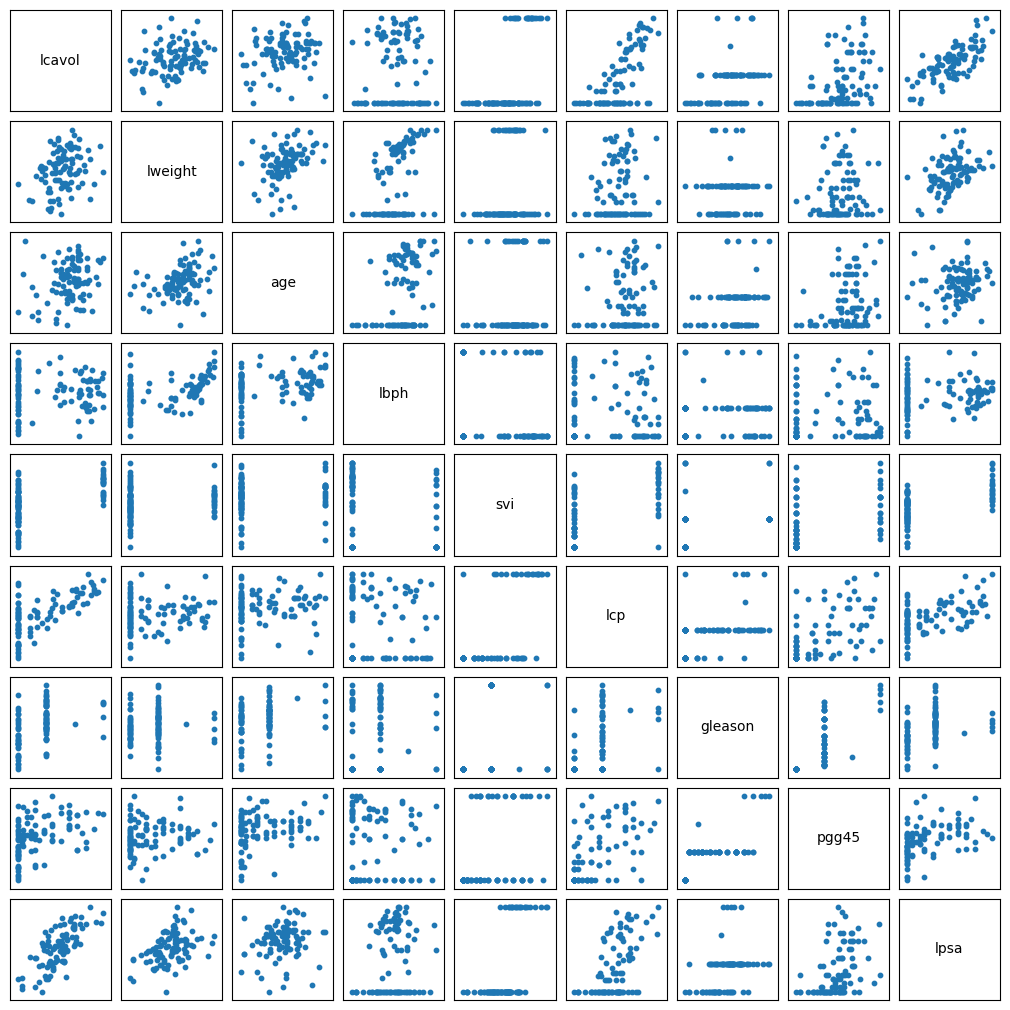

### (c) Variables most correlated with `lcavol`

,"corr(lcavol, x)"
lpsa,0.734460
lcp,0.675310
svi,0.538845
pgg45,0.433652
gleason,0.432417
lweight,0.280521
age,0.225000
lbph,0.027350


From this dataset, the strongest correlations with `lcavol` are `lpsa`, `lcp`, and `svi` (then `pgg45`/`gleason`).

### Inferred predictor datatypes
- Quantitative continuous: `lweight`, `lbph`, `lcp`, `lpsa`
- Quantitative discrete: `age`, `pgg45`
- Binary qualitative: `svi`
- Ordinal qualitative: `gleason`


In [9]:
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# make a pairplot from scratch
def pairplot(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95
    )
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i != j:
                axij.scatter(df[i_name], df[j_name], s=10)
            else:
                axij.text(
                    0.5,
                    0.5,
                    i_name,
                    fontsize=10,
                    horizontalalignment="center",
                    verticalalignment="center",
                    transform=axij.transAxes,
                )
    return fig, ax


display(Markdown("""### (b) What the `pairplot` lines do
- `n_vars = df.shape[1]`: gets the number of variables (columns).
- `plt.subplots(..., ncols=n_vars, nrows=n_vars)`: creates an `n_vars × n_vars` grid of axes.
- `plt.subplots_adjust(...)`: controls spacing/margins to keep the matrix readable.
- Double loop over `(i, j)`: visits each subplot position.
- `i_name`, `j_name`: select which variable goes on x/y for this small plot.
- `set_xticks([]), set_yticks([])`: hides ticks to avoid clutter.
- `margins(0.1)`: adds a little padding around points/text.
- Off-diagonal (`i != j`): scatterplot of two distinct variables.
- Diagonal (`i == j`): writes the variable name instead of plotting it against itself.
- `return fig, ax`: allows post-processing of the generated figure.
"""))

fig, ax = pairplot(df, figsize=(11, 11))
plt.show()

corr_to_lcavol = (
    df.corr(numeric_only=True)["lcavol"]
    .drop("lcavol")
    .sort_values(key=np.abs, ascending=False)
)

display(Markdown("### (c) Variables most correlated with `lcavol`"))
display(corr_to_lcavol.to_frame("corr(lcavol, x)"))

display(Markdown(
    "From this dataset, the strongest correlations with `lcavol` are "
    "`lpsa`, `lcp`, and `svi` (then `pgg45`/`gleason`)."
))

display(Markdown("""### Inferred predictor datatypes
- Quantitative continuous: `lweight`, `lbph`, `lcp`, `lpsa`
- Quantitative discrete: `age`, `pgg45`
- Binary qualitative: `svi`
- Ordinal qualitative: `gleason`
"""))

**(d)** Recall the formula of correlation between two vectors and implement it with `numpy`. Explain the difference of your result when compared to `df.corr()`. Change the function `pairplot`to show the correlation coefficient on the upper triangle of the subplots. (Bonus) Use locally weighted scatterplot smoothing (LOWESS) to see the trends between pairs of features with `statsmodels.nonparametric.smoothers_lowess`.

Max |difference| with pandas corr (ddof=1): 1.055e-15
Max |difference| with pandas corr (ddof=0): 1.055e-15



With `ddof=1`, the manual formula matches `df.corr()` up to floating-point precision.
Differences are numerical (tiny rounding). If `ddof=0` is used, differences appear because
`pandas` computes sample covariance/standard deviation (Bessel correction).


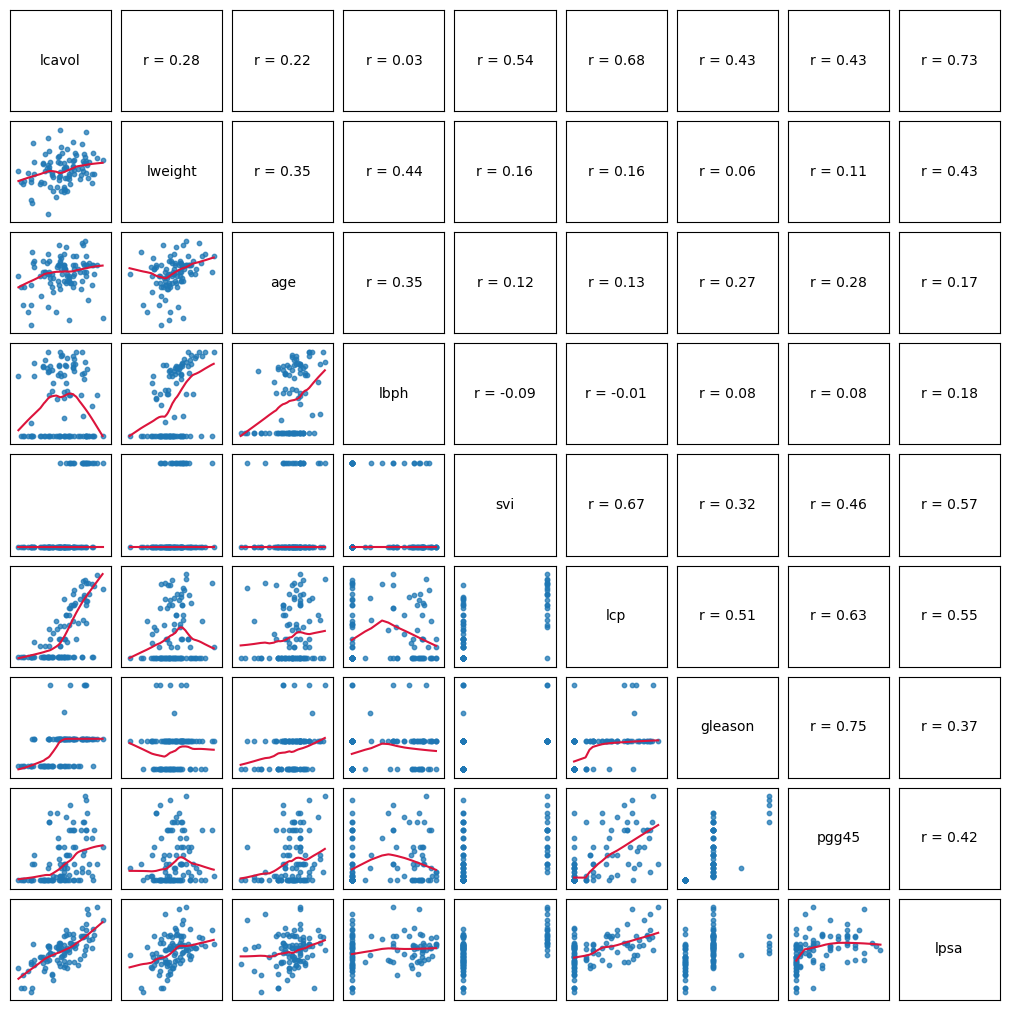

In [10]:
from statsmodels.nonparametric.smoothers_lowess import lowess


def corr_numpy(x, y, ddof=1):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    x_centered = x - x.mean()
    y_centered = y - y.mean()

    cov_xy = np.sum(x_centered * y_centered) / (len(x) - ddof)
    sx = np.sqrt(np.sum(x_centered**2) / (len(x) - ddof))
    sy = np.sqrt(np.sum(y_centered**2) / (len(y) - ddof))

    return cov_xy / (sx * sy)


def corr_matrix_numpy(df_num, ddof=1):
    cols = df_num.columns
    out = pd.DataFrame(index=cols, columns=cols, dtype=float)
    for ci in cols:
        for cj in cols:
            out.loc[ci, cj] = corr_numpy(df_num[ci], df_num[cj], ddof=ddof)
    return out


df_num = df.select_dtypes(include=np.number)
corr_np = corr_matrix_numpy(df_num, ddof=1)
corr_pd = df_num.corr(numeric_only=True)
max_abs_diff = np.abs(corr_np - corr_pd).to_numpy().max()

corr_np_ddof0 = corr_matrix_numpy(df_num, ddof=0)
max_abs_diff_ddof0 = np.abs(corr_np_ddof0 - corr_pd).to_numpy().max()

print(f"Max |difference| with pandas corr (ddof=1): {max_abs_diff:.3e}")
print(f"Max |difference| with pandas corr (ddof=0): {max_abs_diff_ddof0:.3e}")

display(Markdown("""
With `ddof=1`, the manual formula matches `df.corr()` up to floating-point precision.
Differences are numerical (tiny rounding). If `ddof=0` is used, differences appear because
`pandas` computes sample covariance/standard deviation (Bessel correction).
"""))


def pairplot_corr(df, figsize=(11, 11), lowess_frac=0.6):
    num = df.select_dtypes(include=np.number)
    cols = num.columns
    n_vars = len(cols)

    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95
    )

    corr = num.corr(numeric_only=True)

    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i, j]
            xi = cols[j]
            yi = cols[i]

            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)

            if i > j:
                x = num[xi].to_numpy()
                y = num[yi].to_numpy()
                axij.scatter(x, y, s=10, alpha=0.75)

                # LOWESS is informative only with enough distinct x-values
                if np.unique(x).size > 4:
                    smoothed = lowess(y, x, frac=lowess_frac, return_sorted=True)
                    axij.plot(smoothed[:, 0], smoothed[:, 1], color="crimson", lw=1.5)

            elif i < j:
                r = corr.loc[yi, xi]
                axij.text(
                    0.5,
                    0.5,
                    f"r = {r:.2f}",
                    fontsize=10,
                    ha="center",
                    va="center",
                    transform=axij.transAxes,
                )
            else:
                axij.text(
                    0.5,
                    0.5,
                    yi,
                    fontsize=10,
                    ha="center",
                    va="center",
                    transform=axij.transAxes,
                )

    return fig, ax


fig, ax = pairplot_corr(df)
plt.show()

## ▶️ Exercise 2: Linear regression (7 points)

In this exercise, we will perform a multiple linear regression to build a predictive model for the `lcavol` variable. The variables `gleason` and `svi` should be considered as qualitative variables. You can declare them as such with

```
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")
```

**(a)** Provide the mathematical equation of the regression model (note that you can use LaTeX to write equations) and define the diﬀerent parameters. 

In [11]:
from IPython.display import Markdown, display

display(Markdown(r"""
For patient $i$, after one-hot encoding of categorical variables (`svi`, `gleason`),
the multiple linear regression can be written as:

\[
\texttt{lcavol}_i
= \beta_0
+ \beta_1\,\texttt{lweight}_i
+ \beta_2\,\texttt{age}_i
+ \beta_3\,\texttt{lbph}_i
+ \beta_4\,\texttt{lcp}_i
+ \beta_5\,\texttt{pgg45}_i
+ \beta_6\,\texttt{lpsa}_i
+ \gamma\,\mathbf{1}(\texttt{svi}_i=1)
+ \delta_7\,\mathbf{1}(\texttt{gleason}_i=7)
+ \delta_8\,\mathbf{1}(\texttt{gleason}_i=8)
+ \delta_9\,\mathbf{1}(\texttt{gleason}_i=9)
+ \varepsilon_i.
\]

Where:
- $\beta_0$ is the intercept (baseline when all numerical predictors are zero and categories are at reference levels),
- $\beta_1,\ldots,\beta_6$ are slopes for numerical predictors,
- $\gamma,\delta_7,\delta_8,\delta_9$ are category effects relative to references (`svi=0`, `gleason=6`),
- $\varepsilon_i$ is the random error term (mean $0$, variance $\sigma^2$ under the classical model).
"""))


For patient $i$, after one-hot encoding of categorical variables (`svi`, `gleason`),
the multiple linear regression can be written as:

\[
\texttt{lcavol}_i
= \beta_0
+ \beta_1\,\texttt{lweight}_i
+ \beta_2\,\texttt{age}_i
+ \beta_3\,\texttt{lbph}_i
+ \beta_4\,\texttt{lcp}_i
+ \beta_5\,\texttt{pgg45}_i
+ \beta_6\,\texttt{lpsa}_i
+ \gamma\,\mathbf{1}(\texttt{svi}_i=1)
+ \delta_7\,\mathbf{1}(\texttt{gleason}_i=7)
+ \delta_8\,\mathbf{1}(\texttt{gleason}_i=8)
+ \delta_9\,\mathbf{1}(\texttt{gleason}_i=9)
+ \varepsilon_i.
\]

Where:
- $\beta_0$ is the intercept (baseline when all numerical predictors are zero and categories are at reference levels),
- $\beta_1,\ldots,\beta_6$ are slopes for numerical predictors,
- $\gamma,\delta_7,\delta_8,\delta_9$ are category effects relative to references (`svi=0`, `gleason=6`),
- $\varepsilon_i$ is the random error term (mean $0$, variance $\sigma^2$ under the classical model).


**(b)** Before doing the linear regression of this TP, you will first have to handle the one-hot encoding of the categorical features of the dataframe. One way of doing this is as follows:

```
# encode the categorical features with dummy variables
df_enc = pd.get_dummies(df, dtype=np.float64)
# to drop one dummy column for each predictor
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])
# add a column of ones to the dataframe
df_enc['intercept'] = 1
# extract the dataframe for predictors
X = df_enc.drop(columns=['lcavol'])
# get the observed values to predict
y = df['lcavol']
```

- Why did we fix a `dtype` in `pd.get_dummies`?
- Why did we drop two columns after the encoding?
- Why did we add a column of ones to the dataframe?

In [12]:
import statsmodels.api as sm

# Keep a dedicated dataframe for regression work
reg_df = df.copy()
reg_df["svi"] = reg_df["svi"].astype("category")
reg_df["gleason"] = reg_df["gleason"].astype("category")

# One-hot encoding of categorical variables
# dtype=float64 keeps a purely numeric design matrix for linear algebra/statsmodels
reg_enc = pd.get_dummies(reg_df, dtype=np.float64)

# Drop one dummy per categorical predictor (reference categories)
reg_enc = reg_enc.drop(columns=["svi_0", "gleason_6"])

# Add explicit intercept term
reg_enc["intercept"] = 1.0

# Build predictors matrix and response vector
X = reg_enc.drop(columns=["lcavol"])
y = reg_df["lcavol"]

# Fit OLS model
model = sm.OLS(y, X)
results = model.fit()

display(Markdown("""
- **Why fix `dtype` in `get_dummies`?**
  To force dummy columns to be numeric (float64), making matrix operations and model fitting stable and explicit.
- **Why drop `svi_0` and `gleason_6`?**
  To avoid perfect multicollinearity with the intercept (dummy-variable trap). These are reference levels.
- **Why add a column of ones?**
  `statsmodels.OLS` does not add an intercept automatically in this API; this column estimates $\beta_0$.
"""))

results.summary()


- **Why fix `dtype` in `get_dummies`?**
  To force dummy columns to be numeric (float64), making matrix operations and model fitting stable and explicit.
- **Why drop `svi_0` and `gleason_6`?**
  To avoid perfect multicollinearity with the intercept (dummy-variable trap). These are reference levels.
- **Why add a column of ones?**
  `statsmodels.OLS` does not add an intercept automatically in this API; this column estimates $eta_0$.


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 lcavol   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     18.83
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           9.05e-18
Time:                        16:18:28   Log-Likelihood:                -96.825
No. Observations:                  97   AIC:                             215.7
Df Residuals:                      86   BIC:                             244.0
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
lweight       -0.0112      0.211     -0.053      0.958      -0.432       0.409
age            0.0248      0.011      2.205      0.030       0.002       0.047
lbph          -0.1042      0.058     -1.790      0.077      -0.220       0.012
lcp            0.4028      0.085      4.734      0.000       0.234       0.572
pgg45         -0.0094      0.005     -2.080      0.040      -0.018      -0.000
lpsa           0.5496      0.090      6.100      0.000       0.370       0.729
svi_1         -0.2204      0.256     -0.860      0.392      -0.730       0.289
gleason_7      0.3117      0.215      1.448      0.151      -0.116       0.740
gleason_8     -0.7106      0.759     -0.936      0.352      -2.219       0.798
gleason_9      0.7901      0.488      1.621      0.109      -0.179       1.759
intercept     -1.4067      0.874     -1.609      0.111      -3.145       0.332
==============================================================================
Omnibus:                        0.107   Durbin-Watson:                   2.306
Prob(Omnibus):                  0.948   Jarque-Bera (JB):                0.127
Skew:                          -0.073   Prob(JB):                        0.939
Kurtosis:                       2.900   Cond. No.                         884.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**(c)** We will use the [`statsmodels`](https://www.statsmodels.org/) package to estimate the coefficients of the multiple linear regression as per:

```
# import required package
import statsmodels.api as sm
# this line does not fit the regression model per se but only builds it
model = sm.OLS(y, X)
# now we actually fit the model, e.g. calculate all of regression parameters
results = model.fit()
```

Use command `results.sumary()` to get the statistical summary of the estimated coefficients. 

- Explain to what correspond the regression coeﬃcients for the lines related to `svi` and `gleason`. 

- What would have happened in the regression if we did not do the one-hot encoding from above?

- Comment the overall results of the regression as well.

### (c) Interpretation of the OLS summary

- The coefficient of `svi_1` is the effect of having `svi=1` **relative to** the reference level `svi=0`, all other predictors fixed.
- Coefficients `gleason_7`, `gleason_8`, `gleason_9` are effects **relative to** the reference level `gleason=6`.

If we had not one-hot encoded:
- Keeping `svi` and `gleason` as categories would fail in this matrix-based OLS setup (non-numeric columns).
- Treating them as integers would impose an artificial linear/metric structure (e.g., "8 is twice 7"), which is not the intended categorical interpretation.

Overall regression comments:
- The model fit is globally good (`R² ≈ 0.686`, adjusted `R² ≈ 0.650`).
- `lpsa` and `lcp` are the strongest significant predictors (very small p-values).
- `age` and `pgg45` are weaker but still significant at the 5% level in this fit.
- Several dummy coefficients (`svi_1`, `gleason_*`) are not significant individually, likely due to overlap with other predictors and limited sample size.

**(d)** Use `results.conf_int` to get confidence intervals of level 95% for all the coeﬃcients of the predictors. Comment the results.

In [13]:
ci_95 = results.conf_int(alpha=0.05)
ci_95.columns = ["2.5%", "97.5%"]
display(ci_95)

# Coefficients whose CI does not include 0
significant_ci = ci_95[(ci_95["2.5%"] > 0) | (ci_95["97.5%"] < 0)]
print("Predictors with 95% CI excluding 0:")
display(significant_ci)

display(Markdown("""
Interpretation:
- If a 95% CI excludes 0, the coefficient is significant at level 5%.
- Here, `lpsa` and `lcp` clearly have positive effects.
- `pgg45` has a small negative effect in this specification.
- Most category dummies (`svi_1`, `gleason_*`) have intervals crossing 0, so their individual effects are uncertain.
"""))

,2.5%,97.5%
lweight,-0.431600,0.409107
age,0.002436,0.047129
lbph,-0.219914,0.011515
lcp,0.233639,0.571880
pgg45,-0.018469,-0.000419
lpsa,0.370474,0.728673
svi_1,-0.730029,0.289190
gleason_7,-0.116263,0.739616
gleason_8,-2.219087,0.797911
gleason_9,-0.179004,1.759273


Predictors with 95% CI excluding 0:


,2.5%,97.5%
age,0.002436,0.047129
lcp,0.233639,0.571880
pgg45,-0.018469,-0.000419
lpsa,0.370474,0.728673



Interpretation:
- If a 95% CI excludes 0, the coefficient is significant at level 5%.
- Here, `lpsa` and `lcp` clearly have positive effects.
- `pgg45` has a small negative effect in this specification.
- Most category dummies (`svi_1`, `gleason_*`) have intervals crossing 0, so their individual effects are uncertain.


**(e)** What can you say about the eﬀects of the `lpsa` variable? Relate your answer to the $p$-value of a hypothesis test and a confidence interval. You can use `results.pvalues`.

In [14]:
beta_lpsa = results.params["lpsa"]
p_lpsa = results.pvalues["lpsa"]
ci_lpsa = ci_95.loc["lpsa"]

print(f"Estimated effect for lpsa: {beta_lpsa:.4f}")
print(f"p-value for H0: beta_lpsa = 0: {p_lpsa:.3e}")
print(f"95% CI for beta_lpsa: [{ci_lpsa['2.5%']:.4f}, {ci_lpsa['97.5%']:.4f}]")

display(Markdown("""
`lpsa` has a strong positive effect on `lcavol` in the multivariate model:
- the p-value is extremely small, so we reject $H_0: \beta_{lpsa}=0$;
- the 95% confidence interval is fully above 0, confirming a positive association.
"""))

Estimated effect for lpsa: 0.5496
p-value for H0: beta_lpsa = 0: 2.939e-08
95% CI for beta_lpsa: [0.3705, 0.7287]



`lpsa` has a strong positive effect on `lcavol` in the multivariate model:
- the p-value is extremely small, so we reject $H_0: eta_{lpsa}=0$;
- the 95% confidence interval is fully above 0, confirming a positive association.


**(f)** Implement yourself a function that calculates the values of the parameters and their corresponding $p$-values. Bonus: explain why `numpy.linalg.inv` is not necessarily the best choice for estimating the parameters as compared to `numpy.linalg.solve`.

In [15]:
from scipy import stats


def ols_numpy_with_pvalues(X_df, y_series):
    X_np = X_df.to_numpy(dtype=float)
    y_np = y_series.to_numpy(dtype=float)

    n, p = X_np.shape
    XtX = X_np.T @ X_np
    Xty = X_np.T @ y_np

    # Prefer solve(A, b) over inv(A) @ b for numerical stability
    beta_hat = np.linalg.solve(XtX, Xty)

    y_hat = X_np @ beta_hat
    resid = y_np - y_hat

    dof = n - p
    rss = float(resid @ resid)
    sigma2_hat = rss / dof

    cov_beta = sigma2_hat * np.linalg.inv(XtX)
    se_beta = np.sqrt(np.diag(cov_beta))

    t_stats = beta_hat / se_beta
    p_values = 2 * stats.t.sf(np.abs(t_stats), df=dof)

    out = pd.DataFrame(
        {
            "beta_numpy": beta_hat,
            "se_numpy": se_beta,
            "t_numpy": t_stats,
            "p_numpy": p_values,
        },
        index=X_df.columns,
    )

    return out, y_hat, resid


manual_table, y_hat_manual, resid_manual = ols_numpy_with_pvalues(X, y)

comparison = pd.DataFrame(
    {
        "beta_numpy": manual_table["beta_numpy"],
        "beta_sm": results.params,
        "p_numpy": manual_table["p_numpy"],
        "p_sm": results.pvalues,
    }
)
comparison["|beta diff|"] = (comparison["beta_numpy"] - comparison["beta_sm"]).abs()
comparison["|p diff|"] = (comparison["p_numpy"] - comparison["p_sm"]).abs()

display(comparison)
print("Max |beta difference|:", comparison["|beta diff|"].max())
print("Max |p-value difference|:", comparison["|p diff|"].max())

display(Markdown("""
**Bonus (inv vs solve):**
- `np.linalg.inv(X.T @ X) @ (X.T @ y)` explicitly computes a matrix inverse, which is usually less stable and less efficient.
- `np.linalg.solve(X.T @ X, X.T @ y)` solves the same linear system directly, typically with better numerical behavior.
"""))

,beta_numpy,beta_sm,p_numpy,p_sm,|beta diff|,|p diff|
lweight,-0.011246,-0.011246,9.577075e-01,9.577075e-01,1.787633e-14,6.761258e-14
age,0.024782,0.024782,3.014993e-02,3.014993e-02,5.273559e-16,2.976785e-15
lbph,-0.104200,-0.104200,7.695609e-02,7.695609e-02,1.526557e-15,3.330669e-15
lcp,0.402760,0.402760,8.577858e-06,8.577858e-06,6.661338e-16,2.744387e-19
pgg45,-0.009444,-0.009444,4.047741e-02,4.047741e-02,1.099815e-15,2.090689e-14
lpsa,0.549573,0.549573,2.939241e-08,2.939241e-08,4.551914e-15,5.098741e-21
svi_1,-0.220419,-0.220419,3.922717e-01,3.922717e-01,2.775558e-17,1.665335e-16
gleason_7,0.311676,0.311676,1.512950e-01,1.512950e-01,2.109424e-15,2.386980e-15
gleason_8,-0.710588,-0.710588,3.516744e-01,3.516744e-01,4.440892e-15,3.053113e-15
gleason_9,0.790135,0.790135,1.087313e-01,1.087313e-01,3.330669e-15,1.318390e-15


Max |beta difference|: 5.5289106626332796e-14
Max |p-value difference|: 6.761258219967203e-14



**Bonus (inv vs solve):**
- `np.linalg.inv(X.T @ X) @ (X.T @ y)` explicitly computes a matrix inverse, which is usually less stable and less efficient.
- `np.linalg.solve(X.T @ X, X.T @ y)` solves the same linear system directly, typically with better numerical behavior.


**(g)** Plot the predicted values of `lcavol` as a function of the actual values. For this, you can can use `results.get_prediction` to get predictions over `X` and then get its `predicted_mean` attribute.

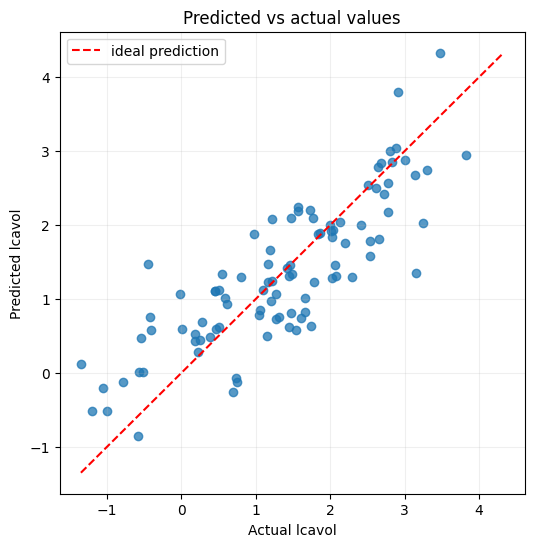

Correlation(actual, predicted): 0.829


In [16]:
pred = results.get_prediction(X)
y_pred = pred.predicted_mean

plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred, alpha=0.75)

vmin = min(y.min(), y_pred.min())
vmax = max(y.max(), y_pred.max())
plt.plot([vmin, vmax], [vmin, vmax], "r--", label="ideal prediction")

plt.xlabel("Actual lcavol")
plt.ylabel("Predicted lcavol")
plt.title("Predicted vs actual values")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print(f"Correlation(actual, predicted): {np.corrcoef(y, y_pred)[0, 1]:.3f}")

**(h)** Plot the histogram of residuals as well as their qq-plot using `statsmodels` function `qqplot`. Can we admit that the residuals are normally distributed? Compute the residual sum of squares (RSS).

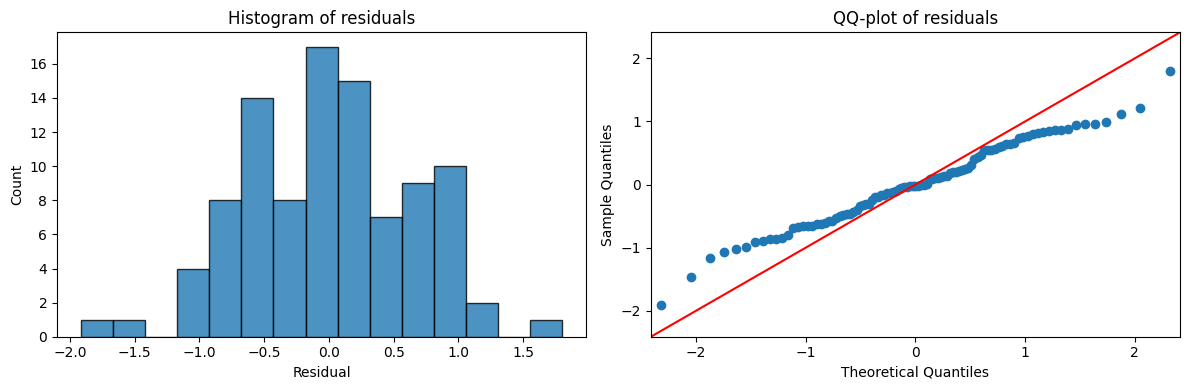

Residual sum of squares (RSS): 41.8141
Jarque-Bera p-value: 0.9386
At 5% level, normality is not rejected.


In [17]:
residuals = results.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(residuals, bins=15, edgecolor="black", alpha=0.8)
axes[0].set_title("Histogram of residuals")
axes[0].set_xlabel("Residual")
axes[0].set_ylabel("Count")

sm.qqplot(residuals, line="45", ax=axes[1])
axes[1].set_title("QQ-plot of residuals")

plt.tight_layout()
plt.show()

rss = float(np.sum(residuals**2))
print(f"Residual sum of squares (RSS): {rss:.4f}")

jb_stat, jb_pvalue, skew, kurtosis = sm.stats.jarque_bera(residuals)
print(f"Jarque-Bera p-value: {jb_pvalue:.4f}")

if jb_pvalue > 0.05:
    print("At 5% level, normality is not rejected.")
else:
    print("At 5% level, normality is rejected.")

**(i)** What happens if predictors `lpsa` and `lcp` are removed from the multiple linear regression model? Note that you can pass a list of strings to `df.columns.drop` method.

In [18]:
X_reduced = X.drop(columns=["lpsa", "lcp"])
results_reduced = sm.OLS(y, X_reduced).fit()

comparison = pd.DataFrame(
    {
        "full_model": [
            results.rsquared,
            results.rsquared_adj,
            results.aic,
            results.bic,
            float(np.sum(results.resid**2)),
        ],
        "without_lpsa_lcp": [
            results_reduced.rsquared,
            results_reduced.rsquared_adj,
            results_reduced.aic,
            results_reduced.bic,
            float(np.sum(results_reduced.resid**2)),
        ],
    },
    index=["R2", "Adj. R2", "AIC", "BIC", "RSS"],
)

display(comparison)

display(Markdown("""
Removing `lpsa` and `lcp` strongly degrades the model:
- lower $R^2$ / adjusted $R^2$,
- higher RSS,
- worse AIC/BIC.

This confirms that these two variables carry a large part of the explanatory power.
"""))

,full_model,without_lpsa_lcp
R2,0.686455,0.432710
Adj. R2,0.649996,0.381138
AIC,215.650697,269.164647
BIC,243.972518,292.337046
RSS,41.814069,75.653233



Removing `lpsa` and `lcp` strongly degrades the model:
- lower $R^2$ / adjusted $R^2$,
- higher RSS,
- worse AIC/BIC.

This confirms that these two variables carry a large part of the explanatory power.


## ▶️ Exercise 3: Best subset selection (5 points)

A regression model that uses $k$ predictors is said to be of size $k$. For instance, 

$$
\texttt{lcavol} = \beta_1 \texttt{lpsa} + \beta_0 + \varepsilon \quad \text{and} \quad \texttt{lcavol} = \beta_1 \texttt{lweight} + \beta_0 + \varepsilon
$$

are models of size one. The regression model without any predictor $\texttt{lcavol} = \beta_0 + \varepsilon$ is a model of size 0.

The goal of this exercise is to select the best model of size $k$ for each $k \in \{0, \dots, 8\}$.

**(a)** Compute the residual sums of squares (RSS) for all models of size $k = 2$. Which model has the smallest RSS? Note that you can use a generator [`itertools.combination`](https://docs.python.org/3/library/itertools.html#itertools.combinations) to automatize for you all the combinations of $k$ elements among $n$.

**(b)** For each value of $k \in \{0, \dots, 8\}$, select the set of predictors that minimizes the RSS. Plot these values as a function of $k$. Provide the names of the selected predictors for each value of $k$.

**(c)** Do you think that minimizing the residual sum of squares is well suited to select the optimal size for the regression models? Justify your answer using what you've learned in class.

,predictors,RSS
0,"(lcp, lpsa)",47.278097
1,"(gleason, lpsa)",57.398830
2,"(svi, lpsa)",58.452188
3,"(pgg45, lpsa)",58.946250
4,"(lbph, lpsa)",59.909789
5,"(age, lpsa)",60.035697
6,"(lweight, lpsa)",61.187121
7,"(lweight, lcp)",68.607649
8,"(age, lcp)",69.930206
9,"(svi, lcp)",70.809173


Best model for k=2: ('lcp', 'lpsa') with RSS = 47.27809728978648


,k,best_predictors,RSS
0,0,(),133.359034
1,1,"(lpsa,)",61.420907
2,2,"(lcp, lpsa)",47.278097
3,3,"(age, lcp, lpsa)",46.237825
4,4,"(age, lbph, lcp, lpsa)",44.878406
5,5,"(age, lbph, lcp, pgg45, lpsa)",44.311332
6,6,"(age, lbph, lcp, gleason, pgg45, lpsa)",43.354252
7,7,"(age, lbph, svi, lcp, gleason, pgg45, lpsa)",43.179048
8,8,"(lweight, age, lbph, svi, lcp, gleason, pgg45,...",43.171699


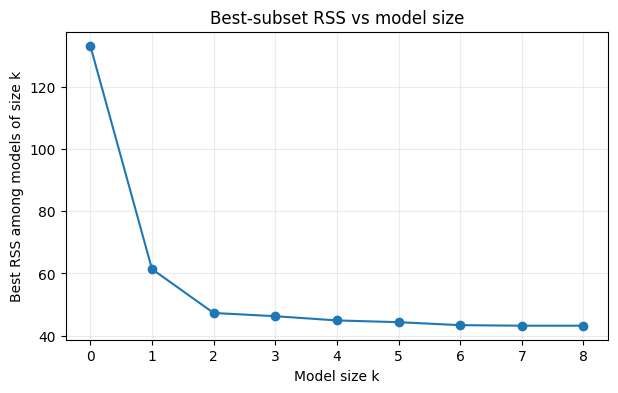


Minimizing RSS alone is **not** suitable to choose the optimal model size:
- RSS is non-increasing when adding predictors, so it systematically favors larger models.
- This can lead to overfitting (excellent training fit, weaker generalization).
- A better choice uses a complexity penalty or out-of-sample performance
  (e.g., adjusted $R^2$, AIC/BIC, split-validation, cross-validation).


In [19]:
from itertools import combinations

target = "lcavol"
predictor_names = [c for c in df.columns if c != target]


def fit_subset(cols):
    cols = list(cols)
    if len(cols) == 0:
        Xk = pd.DataFrame({"const": np.ones(len(df), dtype=float)})
    else:
        Xk = sm.add_constant(df[cols], has_constant="add")

    mk = sm.OLS(df[target], Xk).fit()
    rss_k = float(np.sum(mk.resid**2))
    return mk, rss_k


# (a) All models of size k=2
k2_rows = []
for cols in combinations(predictor_names, 2):
    mk, rss_k = fit_subset(cols)
    k2_rows.append({"predictors": cols, "RSS": rss_k})

k2_df = pd.DataFrame(k2_rows).sort_values("RSS").reset_index(drop=True)
display(k2_df.head(10))
print("Best model for k=2:", k2_df.loc[0, "predictors"], "with RSS =", k2_df.loc[0, "RSS"])


# (b) Best model for each k in {0, ..., 8}
best_models = {}
rss_by_k = []
selected_predictors_by_k = {}

for k in range(0, len(predictor_names) + 1):
    best_rss = np.inf
    best_cols = None
    best_model = None

    for cols in combinations(predictor_names, k):
        mk, rss_k = fit_subset(cols)
        if rss_k < best_rss:
            best_rss = rss_k
            best_cols = cols
            best_model = mk

    best_models[k] = {"predictors": best_cols, "model": best_model, "RSS": best_rss}
    rss_by_k.append(best_rss)
    selected_predictors_by_k[k] = best_cols

best_table = pd.DataFrame(
    {
        "k": list(best_models.keys()),
        "best_predictors": [best_models[k]["predictors"] for k in best_models],
        "RSS": [best_models[k]["RSS"] for k in best_models],
    }
)
display(best_table)

plt.figure(figsize=(7, 4))
plt.plot(best_table["k"], best_table["RSS"], marker="o")
plt.xlabel("Model size k")
plt.ylabel("Best RSS among models of size k")
plt.title("Best-subset RSS vs model size")
plt.grid(alpha=0.25)
plt.show()


# (c) Why RSS alone is not enough
display(Markdown("""
Minimizing RSS alone is **not** suitable to choose the optimal model size:
- RSS is non-increasing when adding predictors, so it systematically favors larger models.
- This can lead to overfitting (excellent training fit, weaker generalization).
- A better choice uses a complexity penalty or out-of-sample performance
  (e.g., adjusted $R^2$, AIC/BIC, split-validation, cross-validation).
"""))

## ▶️ Exercise 4: Split-validation (5 points)

You have now found the best model for each of the nine possible model sizes. In the following, we wish to compare these nine diﬀerent regression models.

**(a)** Give a brief overview of split-validation: how it works? Why it is not subject to the same issues raised in
the item (c) of the previous Exercise?

**(b)** Use function `train_test_split` from the `sklearn` package to split the dataset into a training and a validation (or test) partition. You can set `test_size=0.3`. For each of the nine models from before (i.e. those that minimized the RSS for each size $k$), compute the mean prediction error calculated over the samples from the test set and compare it to its corresponding mean training error. Plot a curve for each of these error as a function of size $k$. 

**(c)** Based on the previous results, choose the best model for this dataset, giving the parameter estimates for the model trained on the whole dataset (i.e. without splitting), and explain your choice.

**(d)** What is the main limitation of split-validation ? Illustrate this issue on the cancer dataset. What could
you do to address this problem? Code such alternative method and comment the result. Note that `sklearn` can provide you with many choices. See [here](https://scikit-learn.org/stable/model_selection.html) for more information.


### (a) Brief overview of split-validation
- Split the data into a training part and a validation/test part.
- Fit candidate models on training only.
- Compare them on unseen test samples (generalization error).

Unlike RSS on training data, this gives an out-of-sample criterion, so adding predictors
is no longer automatically rewarded.


,k,train_MSE,test_MSE
0,0,1.300330,1.585356
1,1,0.575518,0.781232
2,2,0.462209,0.575430
3,3,0.450762,0.563736
4,4,0.438152,0.552334
5,5,0.427707,0.562021
6,6,0.426906,0.542101
7,7,0.424193,0.540710
8,8,0.423442,0.546311


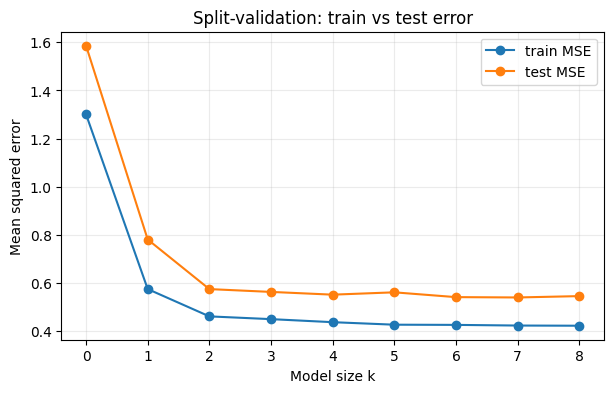

Best model by this split: k=7, predictors=['age', 'lbph', 'svi', 'lcp', 'gleason', 'pgg45', 'lpsa']
Parameter estimates on the whole dataset:


,estimate
const,-2.499954
age,0.021776
lbph,-0.095444
svi,-0.151869
lcp,0.366797
gleason,0.199643
pgg45,-0.007098
lpsa,0.561827


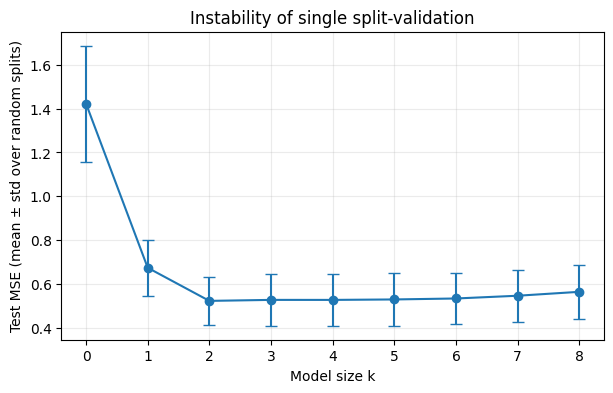

,k,CV_MSE
0,0,1.415072
1,1,0.658585
2,2,0.512494
3,3,0.510105
4,4,0.498083
5,5,0.504496
6,6,0.503873
7,7,0.517225
8,8,0.526993


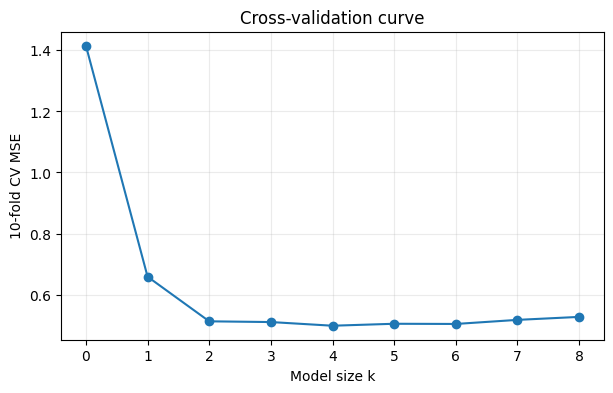

Best model by 10-fold CV: k=4, predictors=['age', 'lbph', 'lcp', 'lpsa']
Full-data coefficients for CV-selected model:


,estimate
const,-1.210220
age,0.020035
lbph,-0.089345
lcp,0.309074
lpsa,0.542728



Cross-validation reduces the dependence on one arbitrary split by averaging over folds,
which usually gives a more stable estimate of prediction error.


In [20]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

display(Markdown("""
### (a) Brief overview of split-validation
- Split the data into a training part and a validation/test part.
- Fit candidate models on training only.
- Compare them on unseen test samples (generalization error).

Unlike RSS on training data, this gives an out-of-sample criterion, so adding predictors
is no longer automatically rewarded.
"""))

X_all = df[predictor_names]
y_all = df[target]

# (b) One split: train/test errors for the 9 best-subset models
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.3, random_state=42
)

ks = sorted(best_models.keys())
train_mse = []
test_mse = []

for k in ks:
    cols = list(best_models[k]["predictors"])

    if k == 0:
        y_train_pred = np.full(len(y_train), y_train.mean())
        y_test_pred = np.full(len(y_test), y_train.mean())
    else:
        lr = LinearRegression()
        lr.fit(X_train[cols], y_train)
        y_train_pred = lr.predict(X_train[cols])
        y_test_pred = lr.predict(X_test[cols])

    train_mse.append(mean_squared_error(y_train, y_train_pred))
    test_mse.append(mean_squared_error(y_test, y_test_pred))

errors_df = pd.DataFrame({"k": ks, "train_MSE": train_mse, "test_MSE": test_mse})
display(errors_df)

plt.figure(figsize=(7, 4))
plt.plot(errors_df["k"], errors_df["train_MSE"], marker="o", label="train MSE")
plt.plot(errors_df["k"], errors_df["test_MSE"], marker="o", label="test MSE")
plt.xlabel("Model size k")
plt.ylabel("Mean squared error")
plt.title("Split-validation: train vs test error")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# (c) Best model from this split and fit it on full data for parameter estimates
best_k_split = int(errors_df.loc[errors_df["test_MSE"].idxmin(), "k"])
best_cols_split = list(best_models[best_k_split]["predictors"])

print(f"Best model by this split: k={best_k_split}, predictors={best_cols_split}")

if best_k_split == 0:
    X_full_best_split = pd.DataFrame({"const": np.ones(len(df), dtype=float)})
else:
    X_full_best_split = sm.add_constant(df[best_cols_split], has_constant="add")

model_best_split_full = sm.OLS(y_all, X_full_best_split).fit()
print("Parameter estimates on the whole dataset:")
display(model_best_split_full.params.to_frame("estimate"))

# (d) Main limitation of split-validation: high variance due to one random split
n_repeats = 300
all_test_mse = np.zeros((n_repeats, len(ks)))
rng = np.random.default_rng(0)

for r in range(n_repeats):
    rs = int(rng.integers(0, 1_000_000_000))
    X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.3, random_state=rs)

    for j, k in enumerate(ks):
        cols = list(best_models[k]["predictors"])

        if k == 0:
            y_hat = np.full(len(y_te), y_tr.mean())
        else:
            lr = LinearRegression().fit(X_tr[cols], y_tr)
            y_hat = lr.predict(X_te[cols])

        all_test_mse[r, j] = mean_squared_error(y_te, y_hat)

mean_test_mse = all_test_mse.mean(axis=0)
std_test_mse = all_test_mse.std(axis=0)

plt.figure(figsize=(7, 4))
plt.errorbar(ks, mean_test_mse, yerr=std_test_mse, fmt="o-", capsize=4)
plt.xlabel("Model size k")
plt.ylabel("Test MSE (mean ± std over random splits)")
plt.title("Instability of single split-validation")
plt.grid(alpha=0.25)
plt.show()

# Alternative: 10-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_mse = []

for k in ks:
    cols = list(best_models[k]["predictors"])

    if k == 0:
        fold_errors = []
        for tr_idx, te_idx in kf.split(X_all):
            y_tr = y_all.iloc[tr_idx]
            y_te = y_all.iloc[te_idx]
            y_hat = np.full(len(y_te), y_tr.mean())
            fold_errors.append(mean_squared_error(y_te, y_hat))
        cv_mse.append(np.mean(fold_errors))
    else:
        lr = LinearRegression()
        scores = cross_val_score(
            lr,
            X_all[cols],
            y_all,
            cv=kf,
            scoring="neg_mean_squared_error",
        )
        cv_mse.append(-scores.mean())

cv_df = pd.DataFrame({"k": ks, "CV_MSE": cv_mse})
display(cv_df)

plt.figure(figsize=(7, 4))
plt.plot(cv_df["k"], cv_df["CV_MSE"], marker="o")
plt.xlabel("Model size k")
plt.ylabel("10-fold CV MSE")
plt.title("Cross-validation curve")
plt.grid(alpha=0.25)
plt.show()

best_k_cv = int(cv_df.loc[cv_df["CV_MSE"].idxmin(), "k"])
best_cols_cv = list(best_models[best_k_cv]["predictors"])
print(f"Best model by 10-fold CV: k={best_k_cv}, predictors={best_cols_cv}")

if best_k_cv == 0:
    X_full_best_cv = pd.DataFrame({"const": np.ones(len(df), dtype=float)})
else:
    X_full_best_cv = sm.add_constant(df[best_cols_cv], has_constant="add")

model_best_cv_full = sm.OLS(y_all, X_full_best_cv).fit()
print("Full-data coefficients for CV-selected model:")
display(model_best_cv_full.params.to_frame("estimate"))

display(Markdown("""
Cross-validation reduces the dependence on one arbitrary split by averaging over folds,
which usually gives a more stable estimate of prediction error.
"""))

## ▶️ Exercise 5: Conclusion (2 points)

What is your conclusion about the choice of the best model to predict `lcavol` ? Comment your results.

In [21]:
split_predictors = list(best_models[best_k_split]["predictors"])
cv_predictors = list(best_models[best_k_cv]["predictors"])

display(Markdown(f"""
### Conclusion

- `lcavol` is strongly linked to `lpsa` and `lcp`, with additional contribution from a few clinical variables.
- Training RSS decreases monotonically with model size, so RSS alone is not enough for model-size choice.
- In one random split, the best test error was obtained for size **k={best_k_split}** with predictors `{split_predictors}`.
- Over repeated folds, a more stable choice was size **k={best_k_cv}** with predictors `{cv_predictors}`.
- Therefore, for this dataset, a medium-size model selected by cross-validation is a good compromise between fit and generalization.
"""))


### Conclusion

- `lcavol` is strongly linked to `lpsa` and `lcp`, with additional contribution from a few clinical variables.
- Training RSS decreases monotonically with model size, so RSS alone is not enough for model-size choice.
- In one random split, the best test error was obtained for size **k=7** with predictors `['age', 'lbph', 'svi', 'lcp', 'gleason', 'pgg45', 'lpsa']`.
- Over repeated folds, a more stable choice was size **k=4** with predictors `['age', 'lbph', 'lcp', 'lpsa']`.
- Therefore, for this dataset, a medium-size model selected by cross-validation is a good compromise between fit and generalization.
